# TabulaX AutoFJ Sweep Results + LLM Call Analysis


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)

TABULAX_ROOT = Path.cwd()
OUTPUTS_DIR = TABULAX_ROOT / "outputs"
ANALYSIS_DIR = TABULAX_ROOT / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

RUN_GLOBS = [
    "autofj_*_fixed10_bothmatch_gpt5mini_sweep",
]
RUN_LABEL = "tabulax_autofj_fixed10_bothmatch_gpt5mini_sweep"
EXPECTED_PROVIDER = "openrouter"
EXPECTED_API_MODEL = "openai/gpt-5-mini"

print("TabulaX root:", TABULAX_ROOT)
print("Outputs dir:", OUTPUTS_DIR)
print("Outputs exists:", OUTPUTS_DIR.exists())
print("Run globs:")
for g in RUN_GLOBS:
    print(" -", g)
print("Expected API model:", EXPECTED_API_MODEL)

TabulaX root: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX
Outputs dir: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX\outputs
Outputs exists: True
Run globs:
 - autofj_*_fixed10_bothmatch_gpt5mini_sweep
Expected API model: openai/gpt-5-mini


In [2]:
def parse_output_folder(folder_name: str) -> dict:
    """
    Supported examples:
      autofj_Artwork_fixed10_bothmatch_gpt5mini_sweep
      autofj_Artwork_fixed10_bothmatch_gpt_classifier_gpt5mini_clean
      autofj_Artwork_fixed10_edit_dist_gpt_classifier_sweep
      autofj_Artwork_fixed10_exact_gpt_classifier_sweep
      autofj_Artwork_qgram_gt_filtered_seed0_edit
      autofj_Artwork_qgram_gt_filtered_seed0_exact
    """
    info = {
        "run_folder": folder_name,
        "dataset": None,
        "example_selector": None,
        "example_size": None,
        "seed": None,
        "matching": None,
        "classification_type": None,
        "run_tag": None,
        "api_model_tag": None,
    }

    # Current both-match GPT-5-mini sweep pattern.
    # The per-row matching type is read from _res.csv's matching_type column.
    m = re.match(
        r"^autofj_(?P<dataset>.+)_fixed(?P<example_size>\d+)_bothmatch(?:_(?P<classification_type>gpt_classifier|golden|all_string))?_gpt5mini(?:_(?P<run_tag>.+))?$",
        folder_name,
    )
    if m:
        d = m.groupdict()
        info.update(d)
        info["example_selector"] = "fixed"
        info["example_size"] = int(info["example_size"])
        info["matching"] = "bothmatch"
        info["api_model_tag"] = "gpt5mini"
        if info["classification_type"] is None:
            info["classification_type"] = "gpt_classifier"
        return info

    # Older one-matching-per-folder sweep pattern.
    m = re.match(
        r"^autofj_(?P<dataset>.+)_fixed(?P<example_size>\d+)_(?P<matching>edit_dist|exact)_(?P<classification_type>gpt_classifier|golden|all_string)_(?P<run_tag>.+)$",
        folder_name,
    )
    if m:
        d = m.groupdict()
        info.update(d)
        info["example_selector"] = "fixed"
        info["example_size"] = int(info["example_size"])
        return info

    # Older manifest/qgram pattern.
    m = re.match(
        r"^autofj_(?P<dataset>.+?)_(?P<selector>.+?)_seed(?P<seed>\d+)_(?P<matching>edit|edit_dist|exact)(?:_(?P<run_tag>.+))?$",
        folder_name,
    )
    if m:
        d = m.groupdict()
        info["dataset"] = d["dataset"]
        info["example_selector"] = d["selector"]
        info["seed"] = int(d["seed"])
        info["matching"] = "edit_dist" if d["matching"] == "edit" else d["matching"]
        info["run_tag"] = d.get("run_tag")
        return info

    # Fallback.
    if folder_name.startswith("autofj_"):
        info["dataset"] = folder_name[len("autofj_"):]
    return info


def safe_json_load(path: Path) -> dict:
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as e:
        print(f"Could not read {path}: {e}")
        return {}


def clean_key(value) -> str:
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(value)).strip("_")


def flatten_llm_summary(summary: dict) -> dict:
    out = {}

    base_keys = [
        "dataset", "ds_name", "ds_path", "model_name", "prompt_version", "basic_prompt",
        "example_size", "example_size_type", "matching_type", "classification_type",
        "total_events", "live_calls", "cache_hits", "success", "error",
        "total_duration_sec", "completed",
    ]
    for k in base_keys:
        out[f"llm_{k}"] = summary.get(k)

    token_usage = summary.get("token_usage") or {}
    for k, v in token_usage.items():
        out[f"llm_{k}"] = v

    stages = summary.get("stages") or {}
    for stage, vals in stages.items():
        stage_clean = clean_key(stage)
        for k, v in (vals or {}).items():
            out[f"llm_stage_{stage_clean}_{k}"] = v

    models = summary.get("models") or {}
    out["llm_models"] = ";".join(models.keys())
    return out


def preview(value, n=500):
    if value is None:
        return None
    if isinstance(value, (dict, list)):
        value = json.dumps(value, ensure_ascii=False, default=str)
    else:
        value = str(value)
    return value.replace("\n", "\\n")[:n]


def read_llm_calls(calls_path: Path, meta: dict) -> list[dict]:
    rows = []
    if not calls_path.exists():
        return rows

    with calls_path.open("r", encoding="utf-8", errors="replace") as f:
        for event_index, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            try:
                ev = json.loads(line)
            except Exception as e:
                rows.append({
                    **meta,
                    "event_index": event_index,
                    "parse_error": str(e),
                    "raw_line_preview": preview(line),
                })
                continue

            token_usage = ev.get("token_usage") or {}
            request_obj = ev.get("messages") or ev.get("request") or ev.get("prompt")
            response_obj = ev.get("response_text") or ev.get("response") or ev.get("completion")

            rows.append({
                **meta,
                "event_index": event_index,
                "timestamp": ev.get("timestamp"),
                "stage": ev.get("stage"),
                "table": ev.get("table"),
                "table_index": ev.get("table_index"),
                "provider": ev.get("provider"),
                "model": ev.get("model"),
                "model_name": ev.get("model_name"),
                "api_model": ev.get("api_model"),
                "api_model_effective": ev.get("api_model") or ev.get("model") or ev.get("model_name"),
                "cached": ev.get("cached"),
                "success": ev.get("success"),
                "error_message": ev.get("error_message"),
                "duration_sec": ev.get("duration_sec"),
                "prompt_tokens": token_usage.get("prompt_tokens"),
                "completion_tokens": token_usage.get("completion_tokens"),
                "total_tokens": token_usage.get("total_tokens"),
                "request_preview": preview(request_obj),
                "response_preview": preview(response_obj),
            })

    return rows


def normalize_bool(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    if s in {"true", "1", "yes"}:
        return True
    if s in {"false", "0", "no"}:
        return False
    return pd.NA


def first_existing_detail_path(run_dir: Path, table_id, matching) -> Path:
    """Both-match runs write Dataset_edit_dist.txt and Dataset_exact.txt."""
    candidates = []
    if pd.notna(table_id) and pd.notna(matching):
        candidates.append(run_dir / f"{table_id}_{matching}.txt")
    if pd.notna(table_id):
        candidates.append(run_dir / f"{table_id}.txt")
    for p in candidates:
        if p.exists():
            return p
    return candidates[0] if candidates else run_dir / "UNKNOWN.txt"

## Load results

In [3]:
run_dirs = []
seen = set()
for glob in RUN_GLOBS:
    for p in sorted(OUTPUTS_DIR.glob(glob)):
        if p.is_dir() and p not in seen:
            run_dirs.append(p)
            seen.add(p)

run_dirs = sorted(run_dirs, key=lambda p: p.name)
print("Matched run directories:", len(run_dirs))
for p in run_dirs:
    print(" -", p.name)

Matched run directories: 50
 - autofj_Amphibian_fixed10_bothmatch_gpt5mini_sweep
 - autofj_ArtificialSatellite_fixed10_bothmatch_gpt5mini_sweep
 - autofj_Artwork_fixed10_bothmatch_gpt5mini_sweep
 - autofj_Award_fixed10_bothmatch_gpt5mini_sweep
 - autofj_BasketballTeam_fixed10_bothmatch_gpt5mini_sweep
 - autofj_Case_fixed10_bothmatch_gpt5mini_sweep
 - autofj_ChristianBishop_fixed10_bothmatch_gpt5mini_sweep
 - autofj_ClericalAdministrativeRegion_fixed10_bothmatch_gpt5mini_sweep
 - autofj_Country_fixed10_bothmatch_gpt5mini_sweep
 - autofj_Device_fixed10_bothmatch_gpt5mini_sweep
 - autofj_Drug_fixed10_bothmatch_gpt5mini_sweep
 - autofj_Election_fixed10_bothmatch_gpt5mini_sweep
 - autofj_Enzyme_fixed10_bothmatch_gpt5mini_sweep
 - autofj_EthnicGroup_fixed10_bothmatch_gpt5mini_sweep
 - autofj_FootballLeagueSeason_fixed10_bothmatch_gpt5mini_sweep
 - autofj_FootballMatch_fixed10_bothmatch_gpt5mini_sweep
 - autofj_Galaxy_fixed10_bothmatch_gpt5mini_sweep
 - autofj_GivenName_fixed10_bothmatch_gpt5

In [4]:
result_rows = []
event_rows = []
missing = []

for run_dir in run_dirs:
    res_path = run_dir / "_res.csv"
    summary_path = run_dir / "llm_summary.json"
    calls_path = run_dir / "llm_calls.jsonl"

    meta = parse_output_folder(run_dir.name)
    meta["output_dir"] = str(run_dir)
    meta["res_path"] = str(res_path)
    meta["llm_summary_path"] = str(summary_path) if summary_path.exists() else None
    meta["llm_calls_path"] = str(calls_path) if calls_path.exists() else None

    if not res_path.exists():
        missing.append({**meta, "missing_file": "_res.csv"})
        continue

    llm_summary = safe_json_load(summary_path)
    flat_llm = flatten_llm_summary(llm_summary)

    try:
        df = pd.read_csv(res_path)
    except Exception as e:
        missing.append({**meta, "missing_file": "_res.csv", "error": str(e)})
        continue

    for _, row in df.iterrows():
        item = {**meta, **flat_llm}

        table_id = row.get("id")
        row_matching = row.get("matching_type", row.get("matching", meta.get("matching")))
        if pd.isna(row_matching) or row_matching is None:
            row_matching = meta.get("matching")

        item["table_id"] = table_id
        item["matching"] = row_matching
        item["folder_matching"] = meta.get("matching")
        item["classification_type"] = meta.get("classification_type") or flat_llm.get("llm_classification_type")
        item["class"] = row.get("class")
        item["P"] = row.get("P")
        item["R"] = row.get("R")
        item["F1"] = row.get("F1")
        item["correct"] = row.get("correct")
        item["n_test"] = row.get("len")
        item["gen_functions"] = row.get("gen_functions")
        item["avg_edit_dist"] = row.get("avg_edit_dist")
        item["avg_norm_edit_dist"] = row.get("avg_norm_edit_dist")
        item["time_sec"] = row.get("Time")
        item["detail_txt_path"] = str(first_existing_detail_path(run_dir, table_id, row_matching))
        result_rows.append(item)

    event_rows.extend(read_llm_calls(calls_path, meta))

results = pd.DataFrame(result_rows)
llm_events = pd.DataFrame(event_rows)
missing_files = pd.DataFrame(missing)

numeric_cols = [
    "P", "R", "F1", "correct", "n_test", "gen_functions", "avg_edit_dist",
    "avg_norm_edit_dist", "time_sec", "example_size",
    "llm_total_events", "llm_live_calls", "llm_cache_hits", "llm_success",
    "llm_error", "llm_total_duration_sec", "llm_prompt_tokens",
    "llm_completion_tokens", "llm_total_tokens",
]
for c in numeric_cols:
    if c in results.columns:
        results[c] = pd.to_numeric(results[c], errors="coerce")

if {"correct", "n_test"}.issubset(results.columns):
    results["raw_correct_rate"] = results["correct"] / results["n_test"]

if not llm_events.empty:
    for c in ["duration_sec", "prompt_tokens", "completion_tokens", "total_tokens"]:
        if c in llm_events.columns:
            llm_events[c] = pd.to_numeric(llm_events[c], errors="coerce")
    llm_events["cached_bool"] = llm_events["cached"].map(normalize_bool)

print("Result rows:", len(results))
print("LLM events:", len(llm_events))
print("Missing/problem rows:", len(missing_files))
if not results.empty:
    print("Matching types loaded:", sorted(results["matching"].dropna().astype(str).unique()))

Result rows: 100
LLM events: 4950
Missing/problem rows: 0
Matching types loaded: ['edit_dist', 'exact']


## Main result table

In [5]:
display_cols = [
    "dataset", "matching", "example_selector", "example_size", "classification_type", "run_tag",
    "class", "P", "R", "F1", "correct", "n_test", "raw_correct_rate",
    "avg_edit_dist", "avg_norm_edit_dist", "time_sec",
    "llm_live_calls", "llm_cache_hits", "llm_total_tokens", "llm_models", "run_folder",
]
display_cols = [c for c in display_cols if c in results.columns]

cur = results.copy()
if not cur.empty:
    cur = cur.sort_values(["dataset", "matching", "classification_type", "run_folder"])
    display(cur[display_cols])
else:
    print("No results loaded. Check TABULAX_ROOT, OUTPUTS_DIR, and RUN_GLOBS.")

if not missing_files.empty:
    display(missing_files)

,dataset,matching,example_selector,example_size,classification_type,run_tag,class,P,R,F1,correct,n_test,raw_correct_rate,avg_edit_dist,avg_norm_edit_dist,time_sec,llm_live_calls,llm_cache_hits,llm_total_tokens,llm_models,run_folder
0,Amphibian,edit_dist,fixed,10,gpt_classifier,sweep,General,0.435714,0.424717,0.430145,391,1151,0.339705,10.535187,0.468375,4234.523579,1143,10,625085,openai/gpt-5-mini,autofj_Amphibian_fixed10_bothmatch_gpt5mini_sweep
1,Amphibian,exact,fixed,10,gpt_classifier,sweep,General,0.970223,0.340296,0.503866,391,1151,0.339705,10.535187,0.468375,4237.508992,1143,10,625085,openai/gpt-5-mini,autofj_Amphibian_fixed10_bothmatch_gpt5mini_sweep
2,ArtificialSatellite,edit_dist,fixed,10,gpt_classifier,sweep,General,0.551724,0.516129,0.533333,18,62,0.290323,5.887097,0.404323,260.800009,60,4,33865,openai/gpt-5-mini,autofj_ArtificialSatellite_fixed10_bothmatch_gpt5mini_sweep
3,ArtificialSatellite,exact,fixed,10,gpt_classifier,sweep,General,1.000000,0.290323,0.450000,18,62,0.290323,5.887097,0.404323,265.207407,60,4,33865,openai/gpt-5-mini,autofj_ArtificialSatellite_fixed10_bothmatch_gpt5mini_sweep
4,Artwork,edit_dist,fixed,10,gpt_classifier,sweep,String,0.638009,0.605150,0.621145,56,235,0.238298,9.570213,0.307743,17.963415,2,0,2231,openai/gpt-5-mini,autofj_Artwork_fixed10_bothmatch_gpt5mini_sweep
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,UnitOfWork,exact,fixed,10,gpt_classifier,sweep,String,1.000000,0.000000,0.000000,0,370,0.000000,11.435135,0.240615,10.024607,2,0,1473,openai/gpt-5-mini,autofj_UnitOfWork_fixed10_bothmatch_gpt5mini_sweep
96,Venue,edit_dist,fixed,10,gpt_classifier,sweep,String,0.479885,0.447721,0.463245,0,374,0.000000,12.000000,0.444387,28.703923,2,0,1650,openai/gpt-5-mini,autofj_Venue_fixed10_bothmatch_gpt5mini_sweep
97,Venue,exact,fixed,10,gpt_classifier,sweep,String,1.000000,0.000000,0.000000,0,374,0.000000,12.000000,0.444387,32.261228,2,0,1650,openai/gpt-5-mini,autofj_Venue_fixed10_bothmatch_gpt5mini_sweep
98,Wrestler,edit_dist,fixed,10,gpt_classifier,sweep,General,0.298368,0.281938,0.289921,54,454,0.118943,10.392070,0.613596,3526.851710,441,15,355943,openai/gpt-5-mini,autofj_Wrestler_fixed10_bothmatch_gpt5mini_sweep


## Export combined CSVs

The notebook writes four files for the GPT-5-mini both-match sweep:

```text
analysis/tabulax_autofj_fixed10_bothmatch_gpt5mini_sweep_results.csv
analysis/tabulax_autofj_fixed10_bothmatch_gpt5mini_sweep_llm_events.csv
analysis/tabulax_autofj_fixed10_bothmatch_gpt5mini_sweep_llm_stage_summary.csv
analysis/tabulax_autofj_fixed10_bothmatch_gpt5mini_sweep_concise_results.csv
```

In [6]:
OUT_PREFIX = ANALYSIS_DIR / RUN_LABEL

results_path = Path(str(OUT_PREFIX) + "_results.csv")
events_path = Path(str(OUT_PREFIX) + "_llm_events.csv")
stage_summary_path = Path(str(OUT_PREFIX) + "_llm_stage_summary.csv")

results.to_csv(results_path, index=False)
llm_events.to_csv(events_path, index=False)

if not llm_events.empty:
    def count_live(s):
        return int((s == False).fillna(False).sum())

    def count_cache(s):
        return int((s == True).fillna(False).sum())

    stage_summary = (
        llm_events
        .groupby(["dataset", "stage", "provider", "api_model_effective"], dropna=False)
        .agg(
            events=("event_index", "count"),
            live_calls=("cached_bool", count_live),
            cache_hits=("cached_bool", count_cache),
            duration_sec=("duration_sec", "sum"),
            prompt_tokens=("prompt_tokens", "sum"),
            completion_tokens=("completion_tokens", "sum"),
            total_tokens=("total_tokens", "sum"),
            successes=("success", lambda s: int((s == True).sum())),
            errors=("success", lambda s: int((s == False).sum())),
        )
        .reset_index()
        .sort_values(["dataset", "stage", "api_model_effective"])
    )
else:
    stage_summary = pd.DataFrame()

stage_summary.to_csv(stage_summary_path, index=False)

print("Wrote:", results_path)
print("Wrote:", events_path)
print("Wrote:", stage_summary_path)

Wrote: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX\analysis\tabulax_autofj_fixed10_bothmatch_gpt5mini_sweep_results.csv
Wrote: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX\analysis\tabulax_autofj_fixed10_bothmatch_gpt5mini_sweep_llm_events.csv
Wrote: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX\analysis\tabulax_autofj_fixed10_bothmatch_gpt5mini_sweep_llm_stage_summary.csv


## LLM stage summary

This groups `llm_calls.jsonl` by dataset, stage, provider, and model. Use it to check which steps were live calls versus cache hits.


In [7]:
if not stage_summary.empty:
    display(stage_summary)
else:
    print("No LLM events loaded.")

,dataset,stage,provider,api_model_effective,events,live_calls,cache_hits,duration_sec,prompt_tokens,completion_tokens,total_tokens,successes,errors
0,Amphibian,classifier,openrouter,openai/gpt-5-mini,1,1,0,0.959628,469,63,532,1,0
1,Amphibian,general_predict_bridge,openrouter,openai/gpt-5-mini,1151,1141,10,4162.831070,249169,374678,623847,1151,0
2,Amphibian,general_relation,openrouter,openai/gpt-5-mini,1,1,0,3.841849,284,422,706,1,0
3,ArtificialSatellite,classifier,openrouter,openai/gpt-5-mini,1,1,0,1.363487,434,85,519,1,0
4,ArtificialSatellite,general_predict_bridge,openrouter,openai/gpt-5-mini,62,58,4,253.546446,11007,21737,32744,62,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,Venue,classifier,openrouter,openai/gpt-5-mini,1,1,0,1.479743,473,64,537,1,0
112,Venue,string_transformer,openrouter,openai/gpt-5-mini,1,1,0,6.597042,290,823,1113,1,0
113,Wrestler,classifier,openrouter,openai/gpt-5-mini,1,1,0,1.922974,420,107,527,1,0
114,Wrestler,general_predict_bridge,openrouter,openai/gpt-5-mini,454,439,15,3500.273109,75215,279441,354656,454,0


## OpenRouter / model check

In [8]:
if llm_events.empty:
    print("No LLM events loaded.")
else:
    live_events = llm_events[llm_events["cached_bool"] == False].copy()

    print("Live event model/provider counts:")
    if live_events.empty:
        print("No live events found. This usually means caches were reused or logs are missing cached flags.")
    else:
        display(
            live_events
            .groupby(["provider", "api_model"], dropna=False)
            .size()
            .reset_index(name="events")
            .sort_values("events", ascending=False)
        )

        suspicious = live_events[
            (live_events["provider"] != EXPECTED_PROVIDER) |
            (live_events["api_model"] != EXPECTED_API_MODEL)
        ].copy()

        if suspicious.empty:
            print(f"All live calls use provider={EXPECTED_PROVIDER} and api_model={EXPECTED_API_MODEL}.")
        else:
            print("Check these live events; they do not match the expected provider/model:")
            display(suspicious[["dataset", "stage", "provider", "api_model", "model", "model_name", "cached", "success", "duration_sec"]])

Live event model/provider counts:


,provider,api_model,events
0,openrouter,openai/gpt-5-mini,4644


All live calls use provider=openrouter and api_model=openai/gpt-5-mini.


## LLM event details

In [9]:
event_cols = [
    "dataset", "event_index", "stage", "table", "provider", "api_model", "model",
    "cached", "success", "duration_sec", "prompt_tokens", "completion_tokens", "total_tokens",
    "response_preview", "request_preview",
]
event_cols = [c for c in event_cols if c in llm_events.columns]

if not llm_events.empty:
    display(llm_events[event_cols].sort_values(["dataset", "event_index"]))
else:
    print("No LLM event rows loaded.")

,dataset,event_index,stage,table,provider,api_model,model,cached,success,duration_sec,prompt_tokens,completion_tokens,total_tokens,response_preview,request_preview
0,Amphibian,1,classifier,Amphibian,openrouter,openai/gpt-5-mini,gpt-4o-mini-2024-07-18,False,True,0.959628,469,63,532,General,"[{""role"": ""user"", ""content"": ""Classify the following data transformations into one of the classes.\nClasses: [`String`, `Numbers`, `Algorithmic`, `General`]\n\nString: When The values on both side..."
1,Amphibian,2,general_relation,Amphibian,openrouter,openai/gpt-5-mini,gpt-4o-mini-2024-07-18,False,True,3.841849,284,422,706,Common or outdated scientific name to current accepted common or scientific name,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. Find what is the relationship between the source and target values.\nFormat the answer as [type of source] to [type of..."
2,Amphibian,3,general_predict_bridge,Amphibian,openrouter,openai/gpt-5-mini,gpt-4o-mini-2024-07-18,False,True,2.818394,217,300,517,Glandular Toadlet,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Common or outdated scientific name and target values are current accepted common or scientific n..."
3,Amphibian,4,general_predict_bridge,Amphibian,openrouter,openai/gpt-5-mini,gpt-4o-mini-2024-07-18,False,True,3.632785,218,392,610,Horned Marsupial Frog,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Common or outdated scientific name and target values are current accepted common or scientific n..."
4,Amphibian,5,general_predict_bridge,Amphibian,openrouter,openai/gpt-5-mini,gpt-4o-mini-2024-07-18,False,True,2.539125,219,288,507,Osteocephalus taurinus,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Common or outdated scientific name and target values are current accepted common or scientific n..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4945,Wrestler,452,general_predict_bridge,Wrestler,openrouter,openai/gpt-5-mini,gpt-4o-mini-2024-07-18,False,True,3.762464,168,441,609,Kazuma Sakamoto,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Professional wrestler ring name and target values are wrestler's real name.\nPlease transform th..."
4946,Wrestler,453,general_predict_bridge,Wrestler,openrouter,openai/gpt-5-mini,gpt-4o-mini-2024-07-18,False,True,8.856755,168,1003,1171,Timothy Burke,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Professional wrestler ring name and target values are wrestler's real name.\nPlease transform th..."
4947,Wrestler,454,general_predict_bridge,Wrestler,openrouter,openai/gpt-5-mini,gpt-4o-mini-2024-07-18,False,True,6.750170,164,667,831,Crash Holly,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Professional wrestler ring name and target values are wrestler's real name.\nPlease transform th..."
4948,Wrestler,455,general_predict_bridge,Wrestler,openrouter,openai/gpt-5-mini,gpt-4o-mini-2024-07-18,False,True,3.045532,164,259,423,Melanie Goranson,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Professional wrestler ring name and target values are wrestler's real name.\nPlease transform th..."


## Performance plots


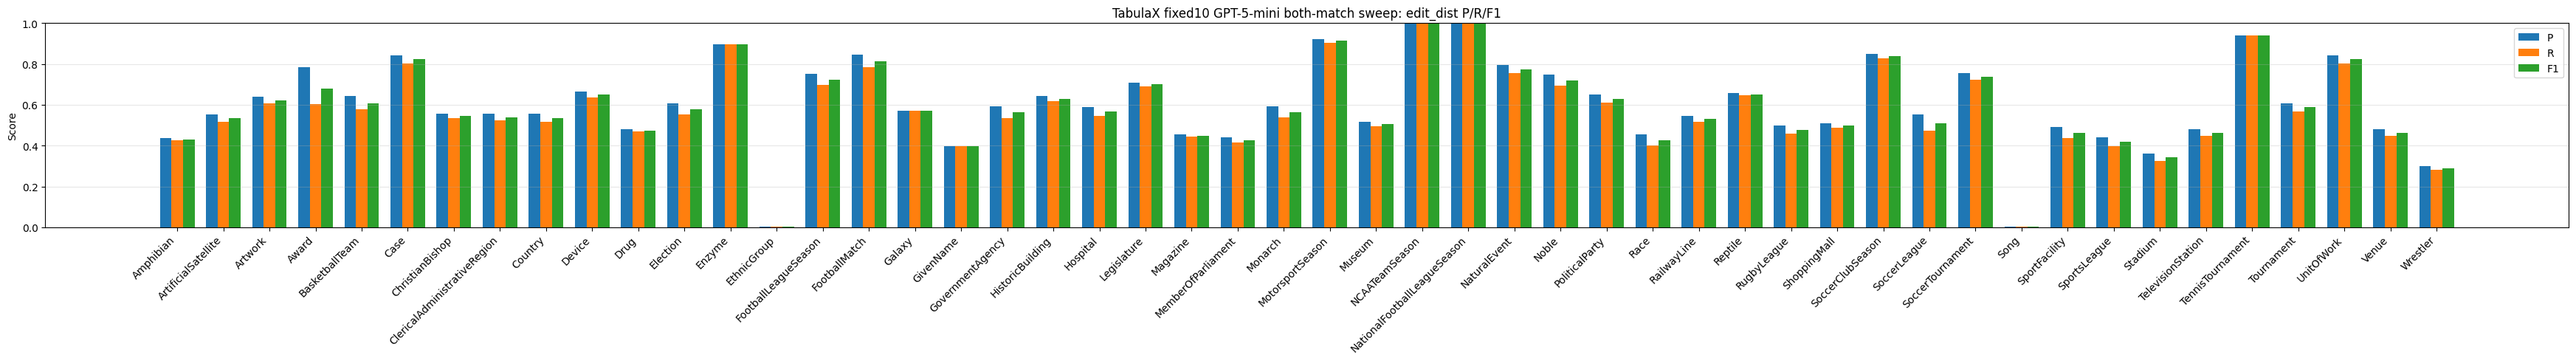

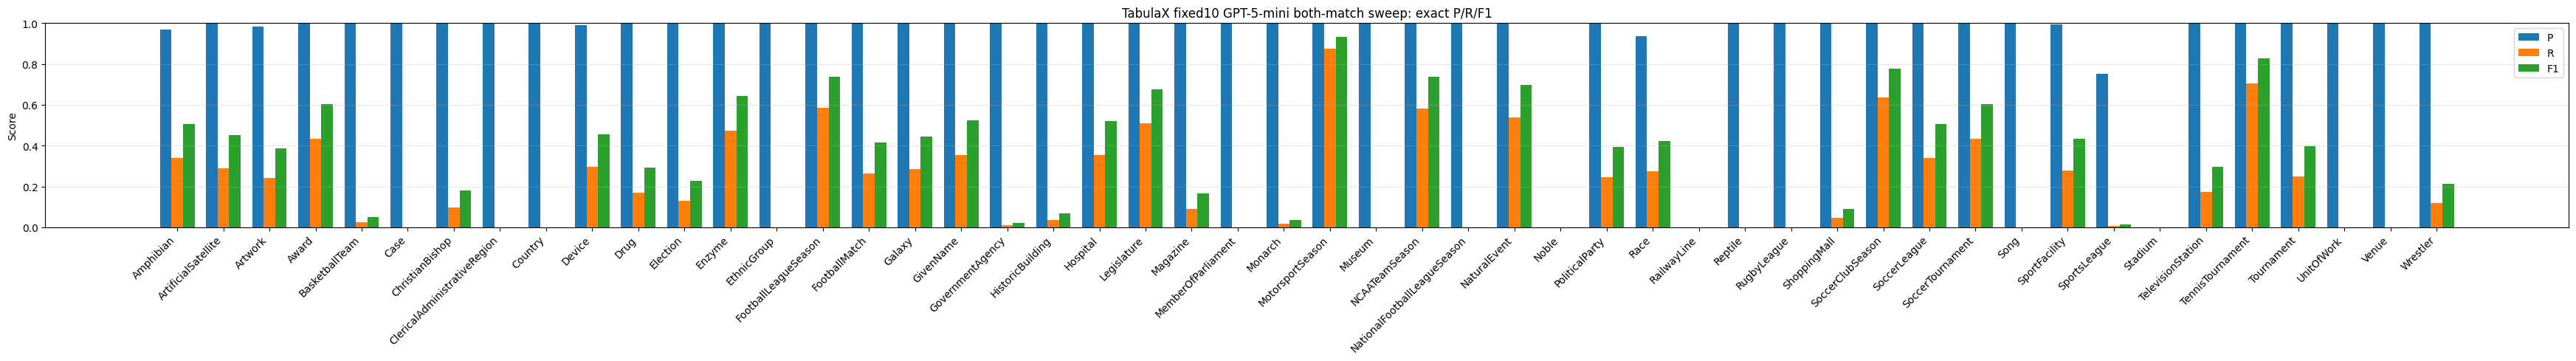

In [10]:
def require_results(df):
    if df.empty:
        print("No rows to plot.")
        return False
    return True


def plot_prf_by_dataset_and_matching(df):
    if not require_results(df):
        return

    for matching in sorted(df["matching"].dropna().astype(str).unique()):
        d = df[df["matching"].astype(str) == matching].sort_values("dataset").copy()
        labels = d["dataset"].astype(str).tolist()
        x = np.arange(len(labels))
        width = 0.25

        fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.7), 5))
        for i, metric in enumerate(["P", "R", "F1"]):
            ax.bar(x + (i - 1) * width, d[metric].values, width, label=metric)

        ax.set_title(f"TabulaX fixed10 GPT-5-mini both-match sweep: {matching} P/R/F1")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.legend()
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_prf_by_dataset_and_matching(cur)

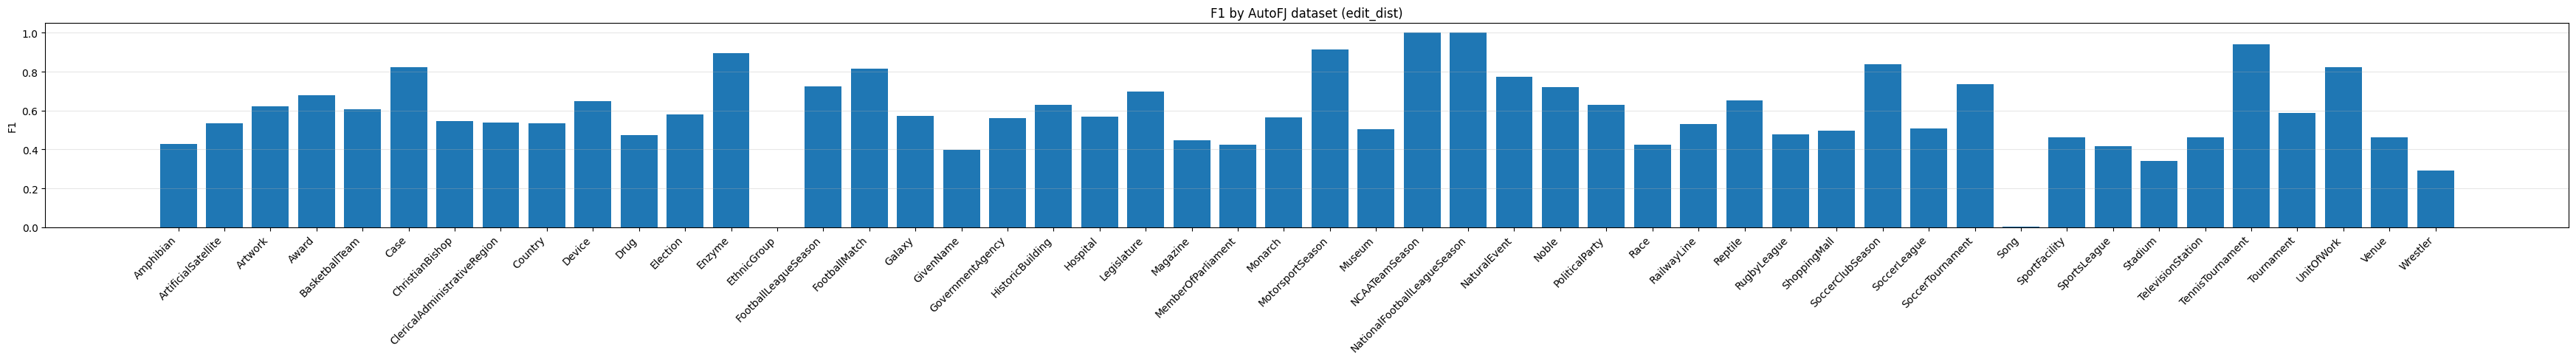

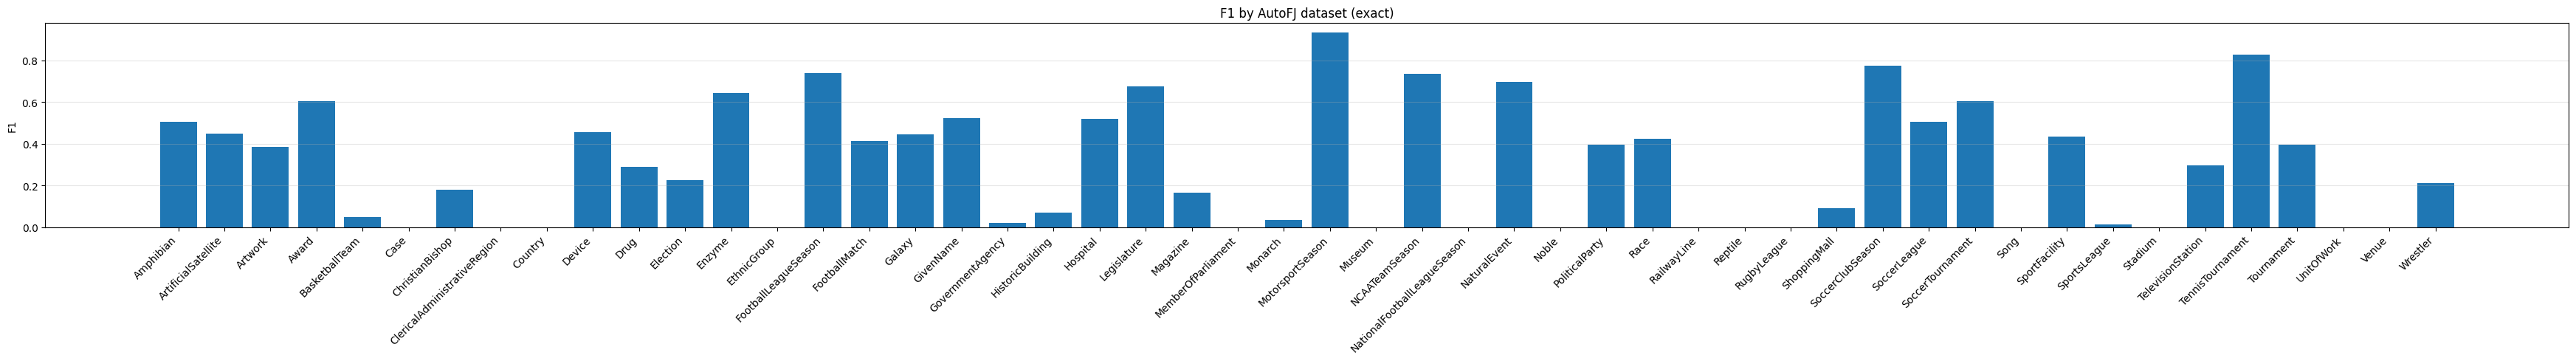

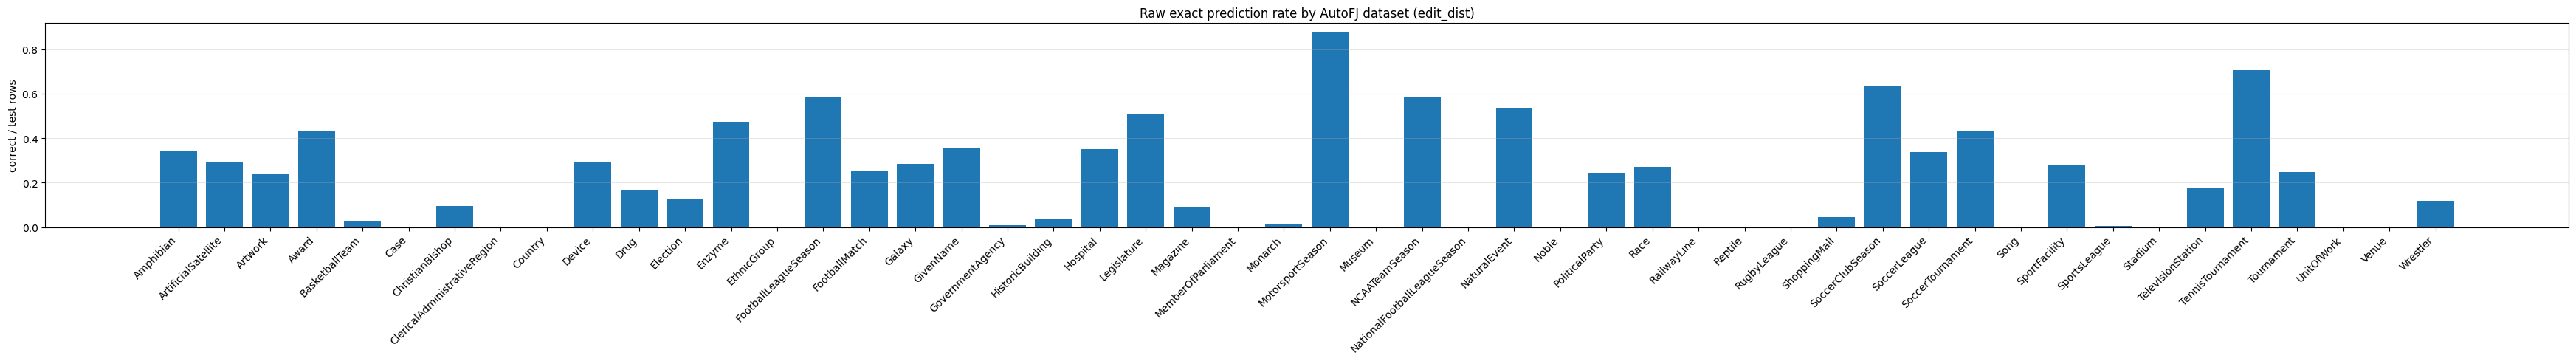

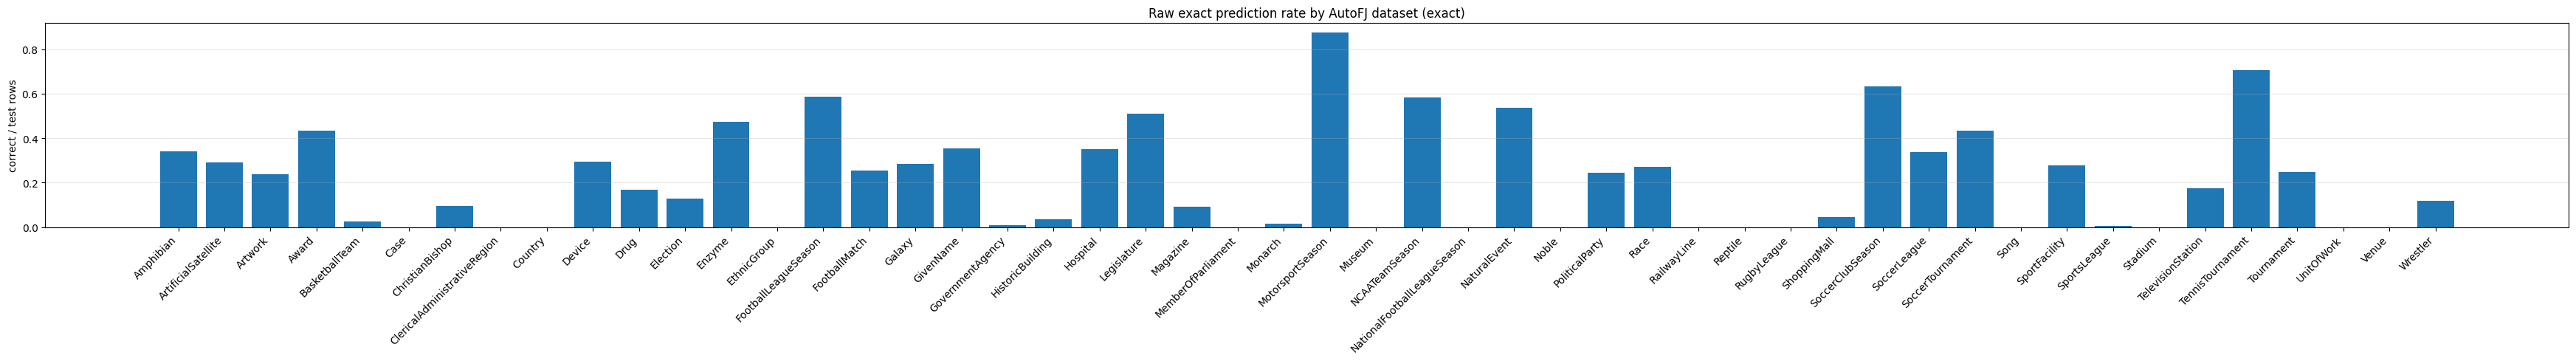

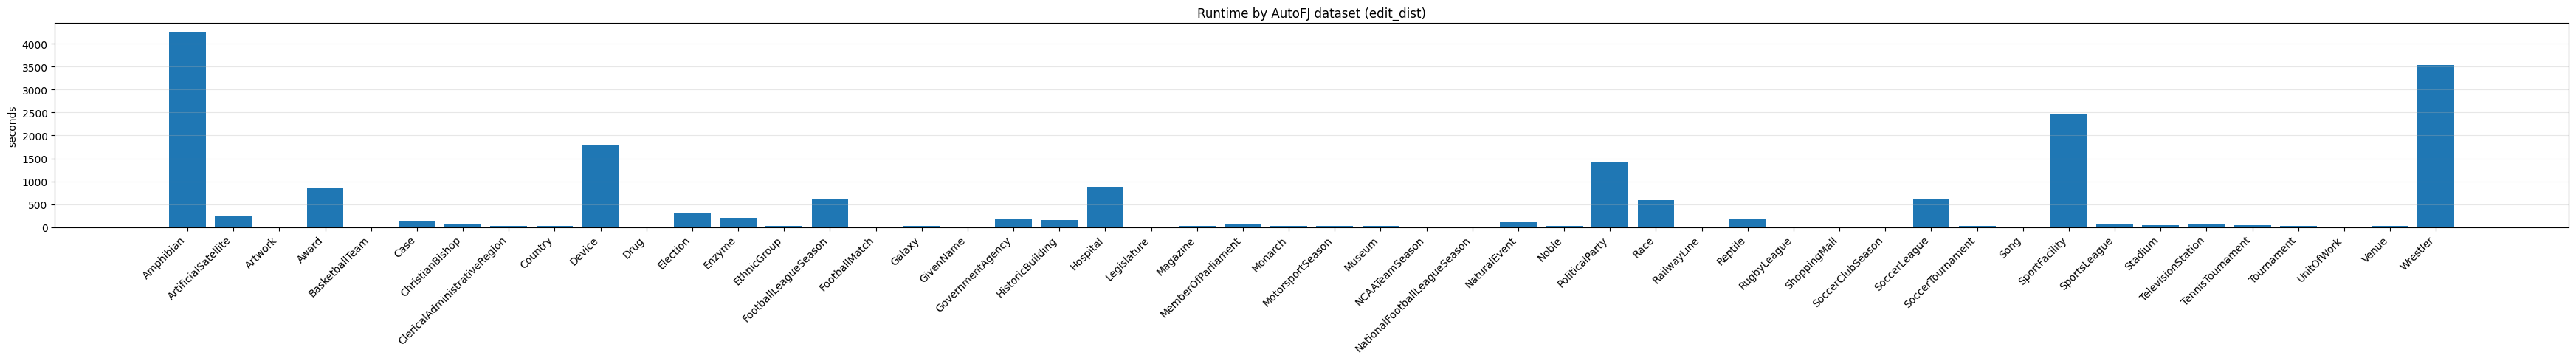

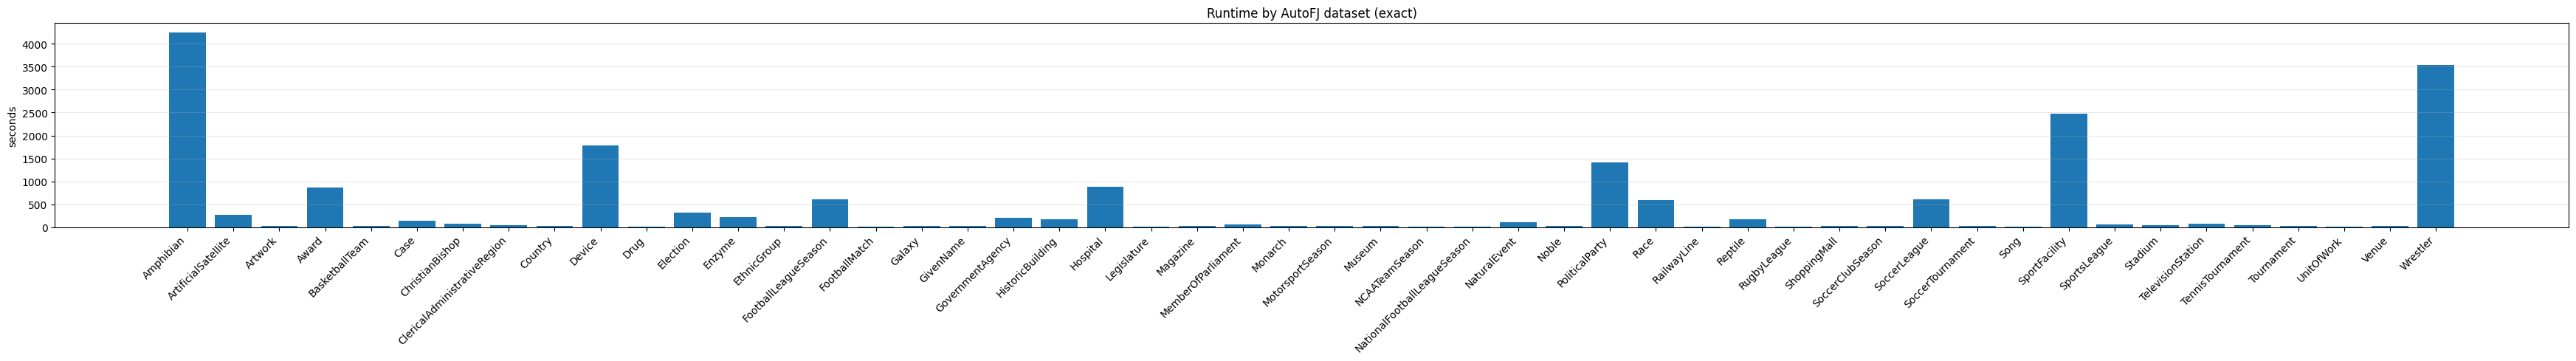

In [11]:
def plot_single_metric(df, metric, title, ylabel=None):
    if not require_results(df):
        return
    if metric not in df.columns:
        print(f"Missing column: {metric}")
        return

    if "matching" in df.columns:
        for matching in sorted(df["matching"].dropna().astype(str).unique()):
            d = df[df["matching"].astype(str) == matching].sort_values("dataset").copy()
            fig, ax = plt.subplots(figsize=(max(10, len(d) * 0.7), 5))
            ax.bar(d["dataset"].astype(str), d[metric])
            ax.set_title(f"{title} ({matching})")
            ax.set_ylabel(ylabel or metric)
            ax.set_xticks(np.arange(len(d)))
            ax.set_xticklabels(d["dataset"].astype(str), rotation=45, ha="right")
            ax.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()
    else:
        d = df.sort_values("dataset").copy()
        fig, ax = plt.subplots(figsize=(max(10, len(d) * 0.7), 5))
        ax.bar(d["dataset"].astype(str), d[metric])
        ax.set_title(title)
        ax.set_ylabel(ylabel or metric)
        ax.set_xticks(np.arange(len(d)))
        ax.set_xticklabels(d["dataset"].astype(str), rotation=45, ha="right")
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_single_metric(cur, "F1", "F1 by AutoFJ dataset", "F1")
plot_single_metric(cur, "raw_correct_rate", "Raw exact prediction rate by AutoFJ dataset", "correct / test rows")
plot_single_metric(cur, "time_sec", "Runtime by AutoFJ dataset", "seconds")

## LLM cost/call plots

These use the aggregated values in `llm_summary.json`. Token counts are only as complete as the LLM logging data returned by the provider/cache.

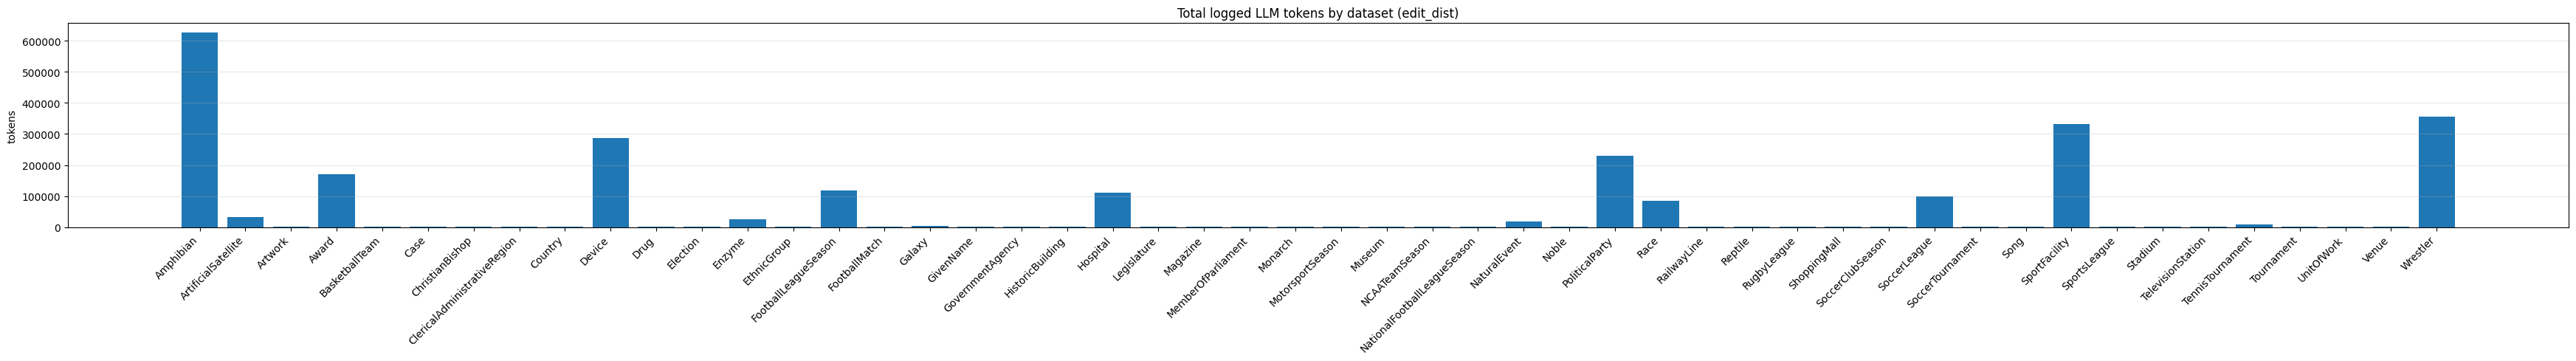

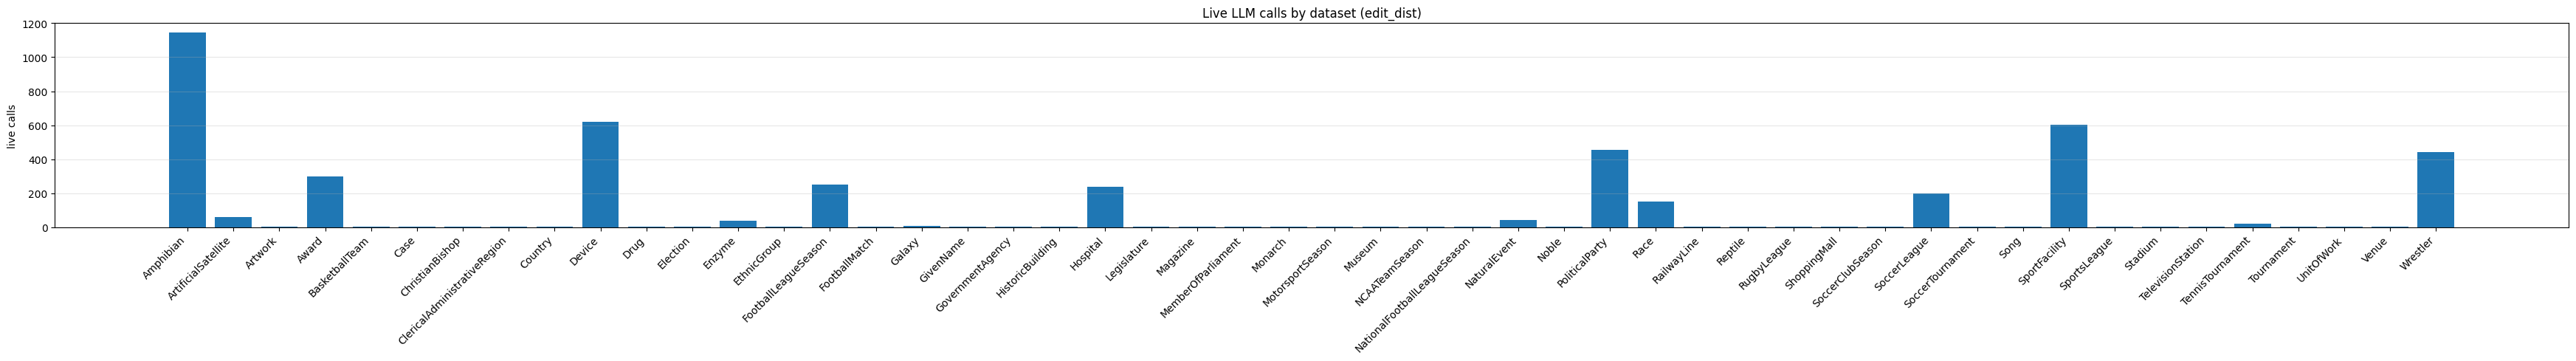

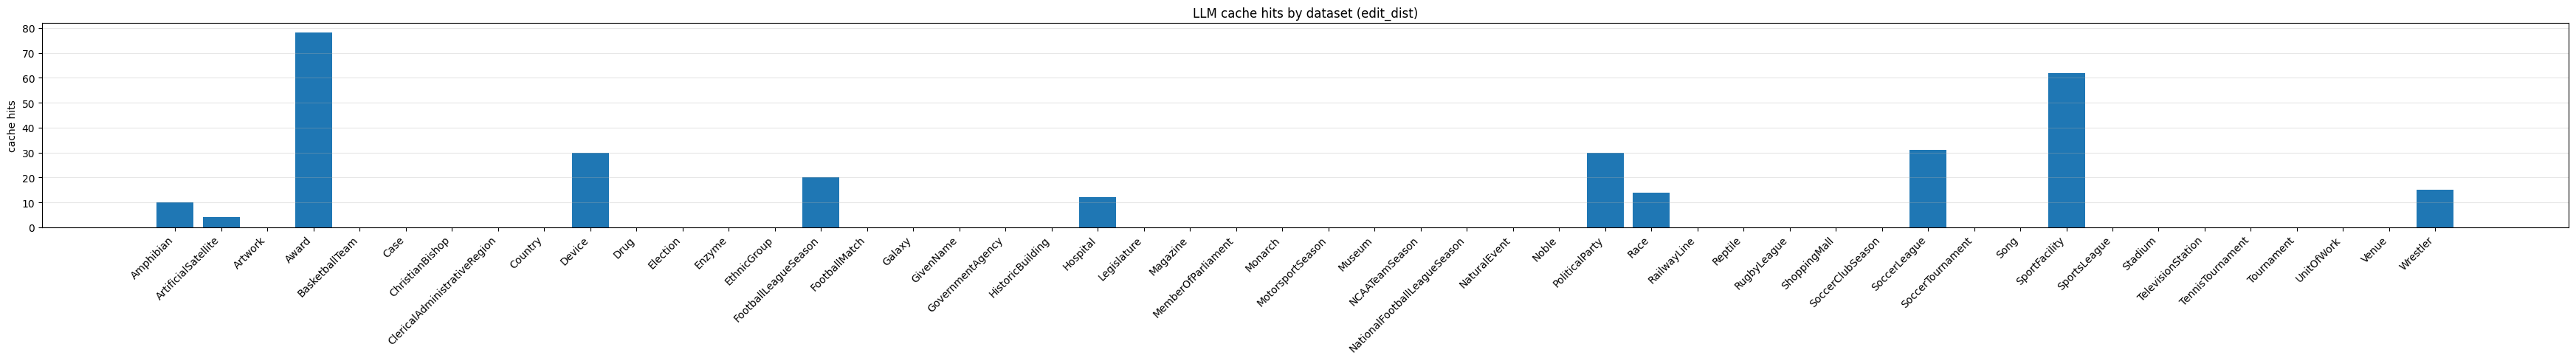

In [12]:
# LLM summary values are per run folder. In both-match runs, edit_dist and exact share the same calls.
# To avoid double-counting in call/token plots, keep one row per output folder.
run_level = cur.drop_duplicates("run_folder").copy() if not cur.empty and "run_folder" in cur.columns else cur.copy()

plot_single_metric(run_level, "llm_total_tokens", "Total logged LLM tokens by dataset", "tokens")
plot_single_metric(run_level, "llm_live_calls", "Live LLM calls by dataset", "live calls")
plot_single_metric(run_level, "llm_cache_hits", "LLM cache hits by dataset", "cache hits")

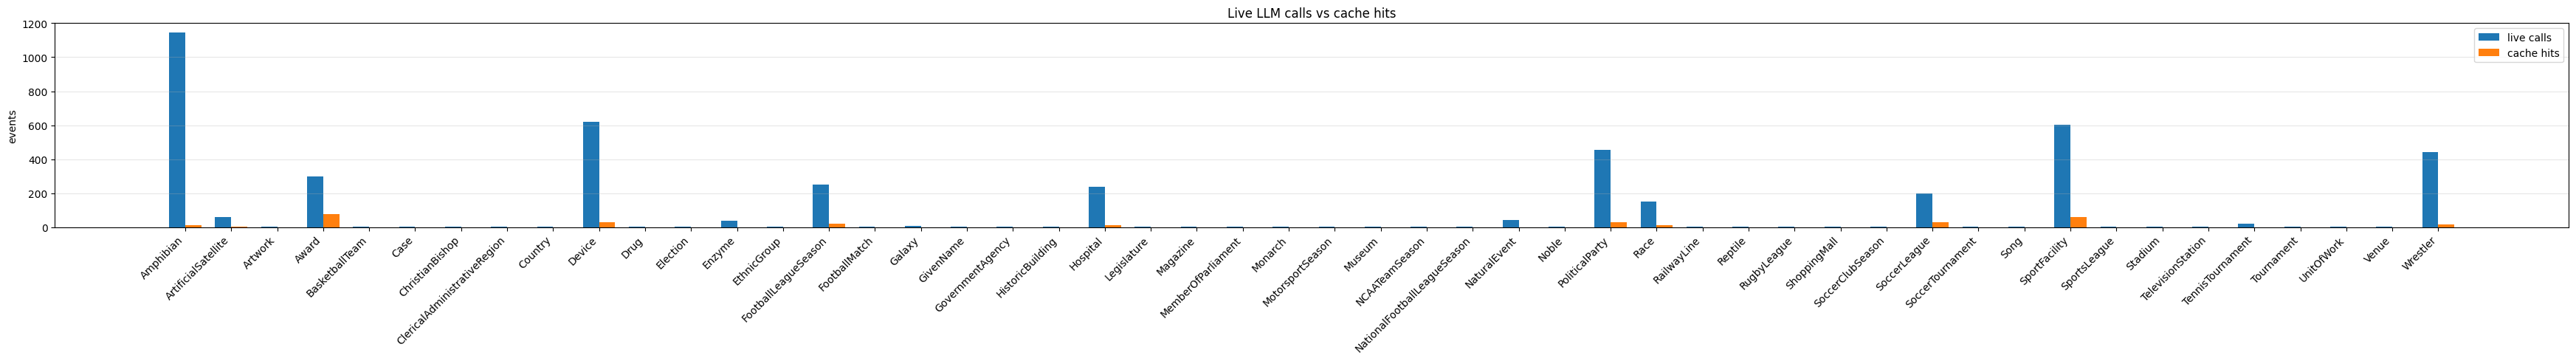

In [13]:
def plot_live_vs_cache(df):
    needed = {"dataset", "llm_live_calls", "llm_cache_hits"}
    if df.empty or not needed.issubset(df.columns):
        print("Need dataset, llm_live_calls, and llm_cache_hits columns.")
        return

    d = df.drop_duplicates("run_folder").sort_values("dataset").copy() if "run_folder" in df.columns else df.sort_values("dataset").copy()
    labels = d["dataset"].astype(str).tolist()
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.7), 5))
    ax.bar(x - width / 2, d["llm_live_calls"], width, label="live calls")
    ax.bar(x + width / 2, d["llm_cache_hits"], width, label="cache hits")
    ax.set_title("Live LLM calls vs cache hits")
    ax.set_ylabel("events")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_live_vs_cache(cur)

## Best / worst datasets by F1


In [14]:
if not cur.empty:
    rank_cols = ["dataset", "matching", "class", "P", "R", "F1", "correct", "n_test", "raw_correct_rate", "time_sec", "llm_live_calls", "llm_total_tokens", "run_folder"]
    rank_cols = [c for c in rank_cols if c in cur.columns]
    display(cur[rank_cols].sort_values(["matching", "F1"], ascending=[True, False]))
else:
    print("No rows loaded.")

,dataset,matching,class,P,R,F1,correct,n_test,raw_correct_rate,time_sec,llm_live_calls,llm_total_tokens,run_folder
54,NCAATeamSeason,edit_dist,String,1.000000,1.000000,1.000000,14,24,0.583333,7.817933,2,1539,autofj_NCAATeamSeason_fixed10_bothmatch_gpt5mini_sweep
56,NationalFootballLeagueSeason,edit_dist,String,1.000000,1.000000,1.000000,0,1,0.000000,11.877307,2,1639,autofj_NationalFootballLeagueSeason_fixed10_bothmatch_gpt5mini_sweep
90,TennisTournament,edit_dist,General,0.941176,0.941176,0.941176,12,17,0.705882,42.189133,19,7892,autofj_TennisTournament_fixed10_bothmatch_gpt5mini_sweep
50,MotorsportSeason,edit_dist,String,0.921833,0.904762,0.913218,330,378,0.873016,21.336323,2,1826,autofj_MotorsportSeason_fixed10_bothmatch_gpt5mini_sweep
24,Enzyme,edit_dist,General,0.894737,0.894737,0.894737,18,38,0.473684,212.232422,40,26172,autofj_Enzyme_fixed10_bothmatch_gpt5mini_sweep
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,RugbyLeague,exact,String,1.000000,0.000000,0.000000,0,48,0.000000,12.368720,2,1658,autofj_RugbyLeague_fixed10_bothmatch_gpt5mini_sweep
81,Song,exact,String,1.000000,0.000000,0.000000,0,430,0.000000,13.546750,2,1644,autofj_Song_fixed10_bothmatch_gpt5mini_sweep
87,Stadium,exact,String,0.000000,0.000000,0.000000,0,609,0.000000,47.017262,2,2122,autofj_Stadium_fixed10_bothmatch_gpt5mini_sweep
95,UnitOfWork,exact,String,1.000000,0.000000,0.000000,0,370,0.000000,10.024607,2,1473,autofj_UnitOfWork_fixed10_bothmatch_gpt5mini_sweep


## Inspect detailed `.txt` output for one dataset

Each run folder has a `DatasetName.txt` file with generated functions, details, processed table rows, and predictions. Use the helper below to preview one of those files directly inside the notebook.


In [15]:
def show_detail(dataset_name: str, matching: str | None = None, max_chars: int = 6000):
    if cur.empty:
        print("No results loaded.")
        return

    matches = cur[cur["dataset"].astype(str).str.lower() == dataset_name.lower()].copy()
    if matching is not None and "matching" in matches.columns:
        matches = matches[matches["matching"].astype(str).str.lower() == matching.lower()]

    if matches.empty:
        print("Available datasets:", sorted(cur["dataset"].dropna().astype(str).unique()))
        if "matching" in cur.columns:
            print("Available matching types:", sorted(cur["matching"].dropna().astype(str).unique()))
        return

    path = Path(matches.iloc[0]["detail_txt_path"])
    print("Detail path:", path)
    if not path.exists():
        print("File does not exist.")
        return

    text = path.read_text(encoding="utf-8", errors="replace")
    print(text[:max_chars])
    if len(text) > max_chars:
        print(f"\n... truncated at {max_chars} characters ...")

# Examples:
# show_detail("Artwork", "edit_dist")
# show_detail("Artwork", "exact")

In [16]:
from pathlib import Path
import pandas as pd

# Use live API calls as "number of LLM calls".
# In both-match runs, edit_dist and exact share the same live calls because they come from one LLM run.
concise = results.copy()

dataset_col = "dataset" if "dataset" in concise.columns else "dataset_from_folder"
needed = [dataset_col, "matching", "P", "R", "llm_live_calls"]
missing_needed = [c for c in needed if c not in concise.columns]
if missing_needed:
    raise KeyError(f"Missing required columns for concise export: {missing_needed}")

concise_results = concise[needed].rename(columns={
    dataset_col: "dataset_name",
    "matching": "matching_type",
    "P": "precision",
    "R": "recall",
    "llm_live_calls": "num_llm_calls",
})

concise_results = concise_results.sort_values(["dataset_name", "matching_type"]).reset_index(drop=True)

out_path = ANALYSIS_DIR / f"{RUN_LABEL}_concise_results.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
concise_results.to_csv(out_path, index=False)

print(f"Wrote: {out_path}")
display(concise_results)

Wrote: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX\analysis\tabulax_autofj_fixed10_bothmatch_gpt5mini_sweep_concise_results.csv


,dataset_name,matching_type,precision,recall,num_llm_calls
0,Amphibian,edit_dist,0.435714,0.424717,1143
1,Amphibian,exact,0.970223,0.340296,1143
2,ArtificialSatellite,edit_dist,0.551724,0.516129,60
3,ArtificialSatellite,exact,1.000000,0.290323,60
4,Artwork,edit_dist,0.638009,0.605150,2
...,...,...,...,...,...
95,UnitOfWork,exact,1.000000,0.000000,2
96,Venue,edit_dist,0.479885,0.447721,2
97,Venue,exact,1.000000,0.000000,2
98,Wrestler,edit_dist,0.298368,0.281938,441
